# Western Pacific projected basemap

Draw Western Pacific basemap templates in the same style as the provided Cartopy/GeoCAT plotting function.

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.default"] = "regular"

OUT_DIR = Path("/Users/lipu/Desktop/2026_MRG_review_comments")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Broader western-Pacific domain. Longitudes are in degrees east.
WESTERN_PACIFIC_EXTENT = [100, 250, -30, 50]

print(f"Figure output directory: {OUT_DIR}")

Figure output directory: /Users/lipu/Desktop/2026_MRG_review_comments


In [23]:
def _format_standard_lon_lat_ticks(ax, extent, lon_step, lat_step):
    xticks = np.arange(extent[0], extent[1] + 1, lon_step)
    yticks = np.arange(extent[2], extent[3] + 1, lat_step)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True, dateline_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(which="major", direction="in", length=4, width=1, pad=8, labelsize=11)


def _set_geocat_lon_lat_ticks(ax, extent, central_lon, lon_step, lat_step):
    import geocat.viz as gv

    lon_range = extent[0:2]
    lat_range = extent[2:4]
    if central_lon == 180:
        xlim = (lon_range[0] - 180, lon_range[1] - 180)
        xticks_vals = np.arange(lon_range[0], lon_range[1] + 1, lon_step) - 180
    else:
        xlim = lon_range
        xticks_vals = np.arange(lon_range[0], lon_range[1] + 1, lon_step)

    gv.set_axes_limits_and_ticks(
        ax,
        xlim=xlim,
        ylim=lat_range,
        xticks=xticks_vals,
        yticks=np.arange(lat_range[0], lat_range[1] + 1, lat_step),
    )
    gv.add_major_minor_ticks(ax, labelsize=11)
    gv.add_lat_lon_ticklabels(ax)
    ax.tick_params(labeltop=False, labelright=False)


def plot_western_pacific_basemap(
    extent=WESTERN_PACIFIC_EXTENT,
    central_lon=180,
    figsize=(14, 7.5),
    title="Western Pacific",
    use_geocat=True,
    show_labels=True,
    add_reference_lines=True,
    land_facecolor="lightgray",
    coastline_color="gray",
    transparent=False,
    save=True,
    basename="western_pacific_basemap_provided_style",
):
    """Draw a Western Pacific basemap following the provided Cartopy/GeoCAT style."""
    if use_geocat:
        try:
            import geocat.viz as gv
        except ImportError:
            print("geocat.viz is not installed; using standard Cartopy axis setup")
            use_geocat = False

    lon_step = 60 if (extent[1] - extent[0]) > 270 else 20
    lat_step = 15 if (extent[3] - extent[2]) > 60 else 10

    fig, ax = plt.subplots(
        1,
        1,
        figsize=figsize,
        subplot_kw={"projection": ccrs.PlateCarree(central_longitude=central_lon)},
    )
    if transparent:
        fig.patch.set_alpha(0)
        ax.patch.set_alpha(0)

    if use_geocat:
        _set_geocat_lon_lat_ticks(ax, extent, central_lon, lon_step, lat_step)
    else:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        _format_standard_lon_lat_ticks(ax, extent, lon_step, lat_step)
        gl = ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False

    if not show_labels:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.tick_params(length=0)

    if land_facecolor is not None:
        ax.add_feature(cfeature.LAND, facecolor=land_facecolor, zorder=0)
    ax.add_feature(cfeature.COASTLINE, edgecolor=coastline_color, linewidth=0.5, zorder=1)
    ax.coastlines(linewidth=0.5, alpha=0.6)

    if add_reference_lines:
        ax.plot(
            [extent[0], extent[1]],
            [0, 0],
            color="gray",
            linewidth=0.8,
            alpha=0.6,
            transform=ccrs.PlateCarree(),
            zorder=2,
        )
        ax.plot(
            [180, 180],
            [extent[2], extent[3]],
            color="gray",
            linewidth=0.8,
            alpha=0.6,
            transform=ccrs.PlateCarree(),
            zorder=2,
        )

    if title:
        if use_geocat:
            gv.set_titles_and_labels(ax, maintitle=title, maintitlefontsize=13)
        else:
            ax.set_title(title, fontsize=13, fontweight="bold", loc="left", pad=8)

    if save:
        png_path = OUT_DIR / f"{basename}.png"
        pdf_path = OUT_DIR / f"{basename}.pdf"
        svg_path = OUT_DIR / f"{basename}.svg"
        fig.savefig(png_path, format="png", dpi=300, bbox_inches="tight", transparent=transparent)
        fig.savefig(pdf_path, format="pdf", dpi=600, bbox_inches="tight", transparent=transparent)
        fig.savefig(svg_path, format="svg", bbox_inches="tight", transparent=transparent)
        print(f"Saved {png_path}")
        print(f"Saved {pdf_path}")
        print(f"Saved {svg_path}")
    return fig, ax

Saved /Users/lipu/Desktop/2026_MRG_review_comments/western_pacific_basemap_provided_style.png
Saved /Users/lipu/Desktop/2026_MRG_review_comments/western_pacific_basemap_provided_style.pdf
Saved /Users/lipu/Desktop/2026_MRG_review_comments/western_pacific_basemap_provided_style.svg


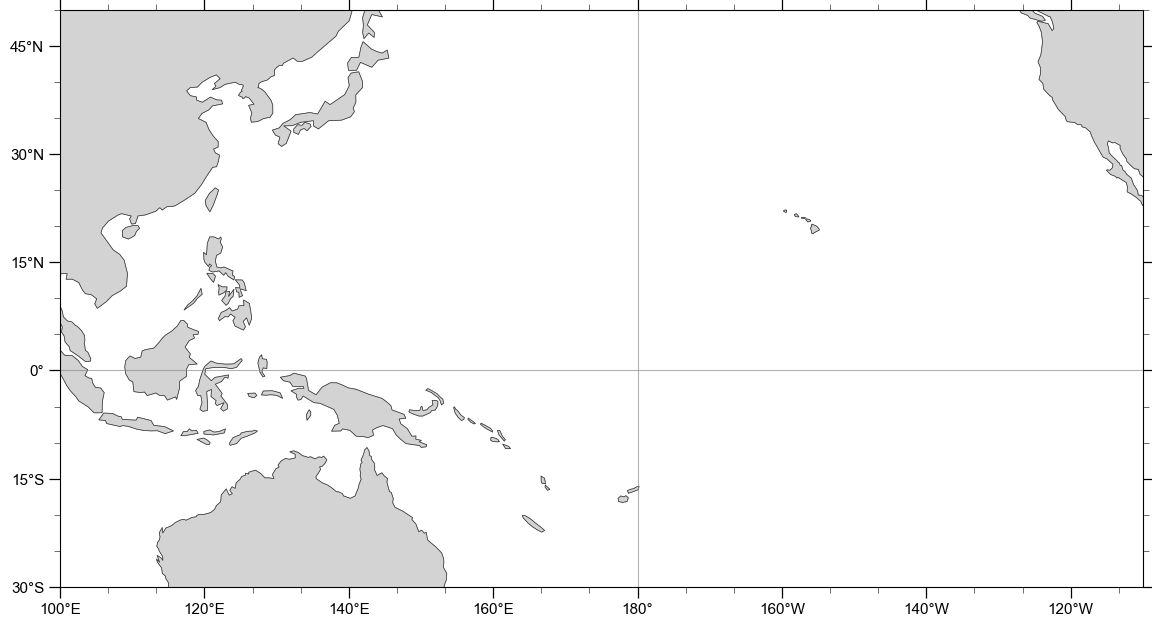

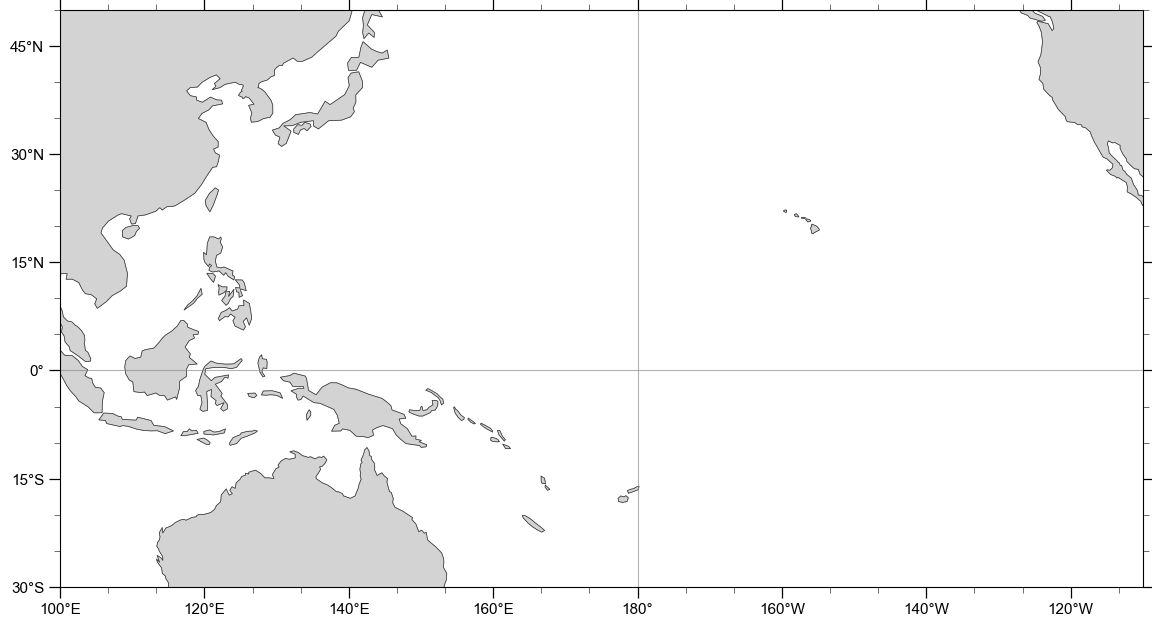

In [24]:
fig, ax = plot_western_pacific_basemap(
    extent=WESTERN_PACIFIC_EXTENT,
    central_lon=180,
    figsize=(14, 7.5),
    title="",
    use_geocat=True,
    show_labels=True,
    add_reference_lines=True,
    land_facecolor="lightgray",
    coastline_color="gray",
    basename="western_pacific_basemap_provided_style",
)
fig

Saved /Users/lipu/Desktop/2026_MRG_review_comments/western_pacific_basemap_provided_style_transparent.png
Saved /Users/lipu/Desktop/2026_MRG_review_comments/western_pacific_basemap_provided_style_transparent.pdf
Saved /Users/lipu/Desktop/2026_MRG_review_comments/western_pacific_basemap_provided_style_transparent.svg


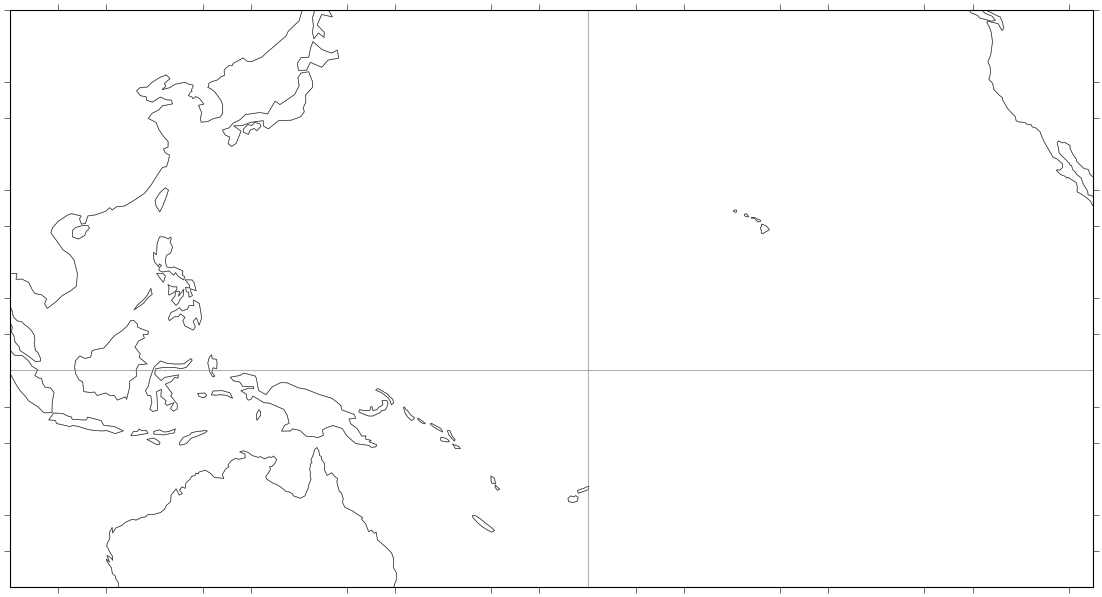

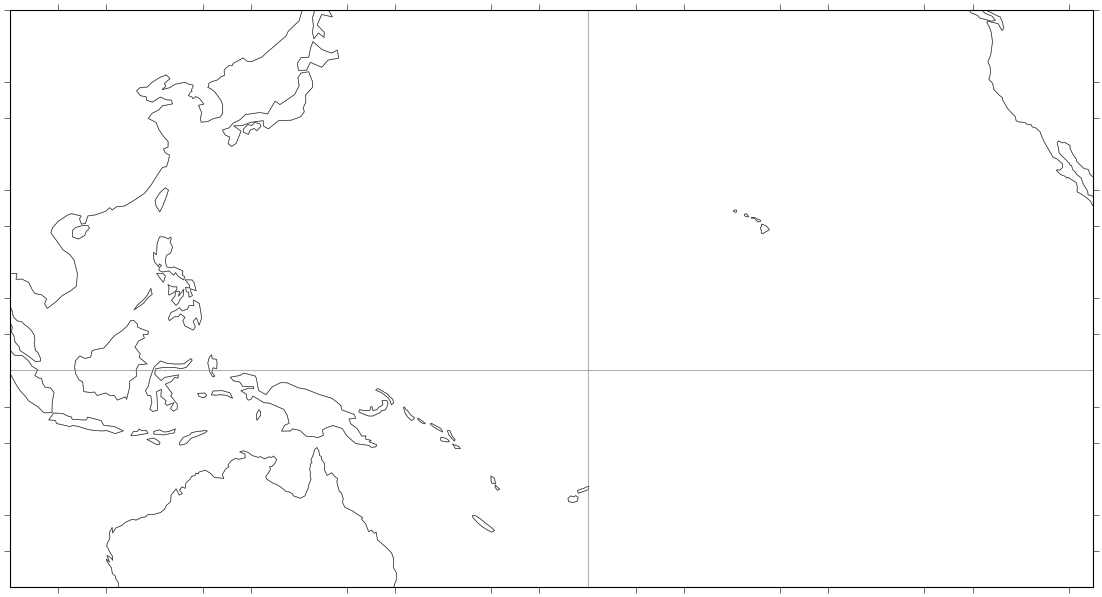

In [25]:
fig, ax = plot_western_pacific_basemap(
    extent=WESTERN_PACIFIC_EXTENT,
    central_lon=180,
    figsize=(14, 7.5),
    title=None,
    use_geocat=True,
    show_labels=False,
    add_reference_lines=True,
    land_facecolor=None,
    coastline_color="gray",
    transparent=True,
    basename="western_pacific_basemap_provided_style_transparent",
)
fig

Future schematic elements can be added on top of either basemap with `transform=ccrs.PlateCarree()`.